# Which spin correlators does each active branch compute?

Produces the manuscript's correlator-regression figure pair for the three active XY
branches identified in the main text's Fig. 4(e)-(f):

| file | manuscript figure |
|---|---|
| `Plots/Fig5.pdf` | Fig. 5, main text (`fig:XY_multilinear_regression`): dominant terms per branch, single column |
| `Plots/Fig5_full.pdf` | Fig. 21, App. F 7: complete coefficient spectrum, double column |

### The question

By the Boolean-Fourier argument developed in the main text's "Interpretable
architecture of TetrisCNN" section and App. B, every branch activation $z[P]$ is,
exactly, a multilinear function of the spin correlators $C[P']$ supported on
subpatterns $P'\subseteq P$ of the branch's filter footprint $P$. Fitting a branch to
*all* of its subpattern correlators therefore recovers $R^2=1$ by construction: this is
a guaranteed algebraic identity, not evidence of anything.

What is genuinely informative, and what this notebook computes, is how much of that
exact fit survives pruning down to a handful of terms. For all three active XY
branches, a single correlator already explains essentially all of the variance
($R^2=1.00$, $0.97$, $0.98$), which is a nontrivial empirical statement about which
physical observables the trained network actually relies on, not a property guaranteed
by the architecture.

The quotable equation therefore comes from a term-selection search over the fitted
coefficients (below), not from ranking the full 15-term fit by coefficient magnitude:
ranking by magnitude alone ignores collinearity between correlators and can pick the
wrong terms.

### What it reads

The trained run lives under `Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2`: the
canonical $6\times7$ XY run, $C_4$-equivariant branches, combined X+Z bases,
$\lambda_{\max}=3$, seed 46 (provenance in `Plots_data/README.md`). Reconstructing the
spin snapshots from that run's `config.json` also requires the experimental
`datasets/` tree, which ships separately from the code (see the README's "Data and
trained runs" section); without it this notebook cannot be re-executed from a fresh
clone.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

from tetriscnn.datasets import create_datasets
from tetriscnn.interpret import fit_activation_to_correlators, orbit_term_labels
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import AttrDict, DEVICE, branch_label, load_json

from tetriscnn.colors import colors

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Configuration

`BASEPATH` points at a **run folder**, the level holding `net1.pt`, `net2.pt` and
`config.json`. For an `lbc`/`partition` experiment that is the `partition_{i}` folder,
not its `seed_{n}` parent.

The term-selection knobs set here (`MAX_TERMS`, `PLATEAU_TOL`, `PLATEAU_FLOOR`) are
explained alongside the fit itself, below.


In [2]:
# Canonical XY model: 6x7 lattice, X+Z bases, C4-equivariant `partition` run,
# lambda_max = 3, seed 46. Provenance in Plots_data/README.md.
BASEPATH = Path("Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2")

CHANNEL_NAMES = ["X", "Z"]  # Paris_XY_XZ channel order

# Term selection: greedy forward path, truncated where R^2 stops rising.
MAX_TERMS = 5         # budget -- how far the importance hierarchy is built
PLATEAU_TOL = 0.05    # keep the shortest prefix within this R^2 of the path's best
PLATEAU_FLOOR = 0.95  # ...but never report an equation weaker than this

N_PANELS = 3            # branches shown, ranked by mean |z|
BRANCH_OVERRIDE = None  # e.g. [0, 2, 1] to pin the panels instead

OUTDIR = Path("Plots")
OUTDIR.mkdir(exist_ok=True)
print(f"run: {BASEPATH}\nexists: {BASEPATH.exists()}")

run: Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
exists: True


## Load the trained run

`load_run` rebuilds the trained TetrisCNN (`net1`, the branch network; `net2`, the task
head) from `config.json` and the saved weights, applies the same stride-padding
compatibility fix used in `FiguresApp_F_lambdamax.ipynb` for legacy kernel specs, reconstructs the
dataset from `datasets/`, and pushes one full split through the network in a single
unshuffled batch, returning the branch activations $z$, the predictions, and the raw
snapshots.

One naming subtlety worth flagging: `create_datasets` returns
`(train_dataset, val_dataset)`, but the line below binds
`val_dataset, _ = create_datasets(cf)`, so the array named `val_dataset` throughout this
notebook actually holds the **training** split (10,124 snapshots), not the held-out
validation split (4,347 snapshots). This regression is a diagnostic readout of the
network's own learned function rather than a generalization test, so fitting it on the
larger split is a reasonable choice, but the variable name should not be read as
"validation" in the usual sense.

The next cell also prints the total snapshot count from `create_datasets`' own
logging, 14,471 samples before the train/validation split. That is the same $n=14471$
quoted in the main text's cross-basis comparison (`app:separate_X_Z_training`), whose
matched X/Z/XZ datasets are built to this run's natural combined size.


In [3]:
def load_run(run_folder: Path):
    """Load config + weights from a run folder and push the val split through the net.

    Returns (cf, snapshots, z, out) with snapshots/z/out as numpy arrays.
    """
    cf = AttrDict()
    cf.update(load_json(str(run_folder), "config.json"))

    # Legacy runs recorded kernels without a stride entry.
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    # Point the config at where it was LOADED from, not where it was first saved.
    cf.logdir = cf.seed_folder = str(run_folder)
    cf.return_all_data = False

    val_dataset, _ = create_datasets(cf)

    net1 = ShapeAdaptiveConvNet(
        in_channels=val_dataset[0][0].shape[0],
        kernels=cf.kernels,
        equivariant=cf.equivariant,
        hidden_size=cf.hidden_size,
        init=cf.init,
        device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel(
        [len(cf.kernels), 32, 16, val_dataset.output_dim], device=DEVICE
    ).to(DEVICE)

    net1.load_state_dict(torch.load(run_folder / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(run_folder / "net2.pt", map_location=DEVICE))
    net1.eval()
    net2.eval()

    loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            z = net1(x)
            out = net2(z)

    return cf, x.cpu().numpy(), z.cpu().numpy(), out.cpu().numpy(), val_dataset

In [4]:
cf, snapshots, z, out, b = load_run(BASEPATH)

# The group is a property of the ARCHITECTURE: pass it for an equivariant branch and
# omit it otherwise. Passing the wrong one (or a group to a plain branch) breaks the
# exact reading rather than improving it.
GROUP = cf.equivariant_group if getattr(cf, "equivariant", False) else None

mean_abs_z = np.abs(z).mean(axis=0)
ranked = np.argsort(mean_abs_z)[::-1]
panel_branches = BRANCH_OVERRIDE or [int(k) for k in ranked[:N_PANELS]]

print(f"equivariant={getattr(cf, 'equivariant', False)}  group={GROUP}  "
      f"branches={len(cf.kernels)}  val snapshots={len(z)}")
print("\nmean |z| per branch (the L1 survival readout):")
for k in ranked:
    star = " <- panel" if k in panel_branches else ""
    print(f"  branch {k:>2}  kernel {str(cf.kernels[k][0]):>6}  mean|z|={mean_abs_z[k]:.4f}{star}")


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples


times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.


equivariant=True  group=C4  branches=5  val snapshots=10124

mean |z| per branch (the L1 survival readout):
  branch  0  kernel [1, 1]  mean|z|=0.5116 <- panel
  branch  1  kernel [2, 1]  mean|z|=0.0437 <- panel
  branch  2  kernel [2, 2]  mean|z|=0.0357 <- panel
  branch  4  kernel [2, 2]  mean|z|=0.0000
  branch  3  kernel [2, 2]  mean|z|=0.0000


## Fit each branch to its correlators

`fit_activation_to_correlators` enumerates every sub-pattern of the branch footprint
(single-basis *and* cross-basis product terms) and fits all of them. That fit is exact
($R^2 = 1$) and unreadable, so the figure needs a pruned form.

The pruning is `select_strategy="forward"`: build a **nested importance hierarchy**,
the single most explanatory correlator, then the best addition given that one, and so
on up to `MAX_TERMS`, then keep the shortest prefix that is *already as good as the
path gets*. Formally, the smallest $k$ with

$$R^2_k \;\ge\; \max\!\big(\max_j R^2_j - \texttt{PLATEAU\_TOL},\;\texttt{PLATEAU\_FLOOR}\big).$$

Both halves matter. The **floor** stops a branch being summarised by a short equation
that is stable but inadequate. The **plateau-against-the-path-maximum** (rather than
"stop at the first small gain") is what survives correlators that are only *jointly*
informative: on the plain XY $2\times1$ branch the path runs
$0.24 \to 0.36 \to 0.45$ and then jumps to $0.99$ on the fourth term, and a
first-small-gain rule would report $R^2 = 0.24$.

This notebook does not set `plateau_sufficient`, the opt-in absolute "good enough" bar
used instead of the tol/floor rule when a path stays strong throughout (as in
`Figure6.ipynb`'s decision-boundary fit). Here the tol/floor rule is already
decisive: as the printed forward paths below show, all three panel branches clear the
floor at their very first term, so the pruned equations plotted in Fig. 5 turn out to
be single-correlator fits despite a budget of five.

Coefficients are always an **unpenalized refit** on the kept support, so they are a
physical readout rather than shrunken ones.


In [5]:
fits = {}
for k in panel_branches:
    # A branch cannot be given a bigger budget than it has terms (the 1x1 branch
    # only offers 3), so clamp rather than raise.
    n_avail = len(fit_activation_to_correlators(
        snapshots, z[:, k], cf.kernels[k], channel_names=CHANNEL_NAMES,
        group=GROUP, verbose=False)["patterns"])

    fits[k] = fit_activation_to_correlators(
        snapshots,
        z[:, k],
        cf.kernels[k],
        channel_names=CHANNEL_NAMES,
        group=GROUP,
        select_terms=min(MAX_TERMS, n_avail),
        select_strategy="forward",
        plateau_tol=PLATEAU_TOL,
        plateau_floor=PLATEAU_FLOOR,
        verbose=False,
    )

print(f"{'branch':>6} {'kernel':>8} {'terms':>6} {'kept':>5} {'R2_kept':>9}   "
      f"forward path R^2 by size")
print("-" * 78)
for k in panel_branches:
    res = fits[k]
    trail = "  ".join(f"{r:.4f}" for _, r in res["selection_path"])
    flag = "" if res["selected_r_squared"] >= PLATEAU_FLOOR else "  <- BELOW FLOOR"
    print(f"{k:>6} {str(cf.kernels[k][0]):>8} {len(res['patterns']):>6} "
          f"{len(res['selected_terms']):>5} {res['selected_r_squared']:>9.4f}   "
          f"{trail}{flag}")

branch   kernel  terms  kept   R2_kept   forward path R^2 by size
------------------------------------------------------------------------------
     0   [1, 1]      3     1    0.9983   0.9983  0.9997  1.0000
     1   [2, 1]     15     1    0.9662   0.9662  0.9853  0.9930  0.9977  0.9986
     2   [2, 2]     15     1    0.9773   0.9773  0.9871  0.9922  0.9950  0.9972


### The importance hierarchy, and where it is cut

The table below is the audit trail behind every equation in the figure: the correlators
in the order the greedy search found them, the running $R^2$, and the marginal gain.
The cut is marked with `<<`.

The last column compares against exhaustive best-subset **at the same size**. Greedy is
not guaranteed optimal at every $k$ (a term can look weak alone yet be strong in
company), so this says how much the nesting costs. Where the two agree, the hierarchy
is not an artefact of the search order.


In [6]:
import statsmodels.api as sm

from tetriscnn.interpret import best_subset_terms


def _r2(res, cols):
    X_ = res["correlators_with_const"]
    return sm.OLS(res["outputs"], X_[:, [0] + list(cols)]).fit().rsquared


for k in panel_branches:
    res = fits[k]
    n_keep = len(res["selected_terms"])
    path = res["selection_path"]
    X_, y = res["correlators_with_const"], res["outputs"]
    print(f"branch {k}  kernel {cf.kernels[k][0]}  "
          f"({len(res['patterns'])} terms available)")
    print(f"   {'step':>4} {'R2':>8} {'gain':>8} {'R2_bestsub':>11}  term")
    prev = 0.0
    for i, (col, r2) in enumerate(path, 1):
        best_at_i = _r2(res, best_subset_terms(X_, y, i)[0])
        mark = "<<" if i == n_keep else "  "
        print(f"{mark} {i:>4} {r2:>8.4f} {r2 - prev:>+8.4f} {best_at_i:>11.4f}"
              f"  {res['patterns'][col - 1]}")
        prev = r2
    if res["selected_r_squared"] < PLATEAU_FLOOR:
        print(f"   WARNING: budget exhausted at R2={res['selected_r_squared']:.4f}, "
              f"below the floor {PLATEAU_FLOOR}: no adequate short form exists.")
    print()

branch 0  kernel [1, 1]  (3 terms available)
   step       R2     gain  R2_bestsub  term
<<    1   0.9983  +0.9983      0.9983  $\substack{X:\blacksquare \\ Z:\square}$
      2   0.9997  +0.0014      0.9997  $\substack{X:\square \\ Z:\blacksquare}$
      3   1.0000  +0.0003      1.0000  $\substack{X:\blacksquare \\ Z:\blacksquare}$

branch 1  kernel [2, 1]  (15 terms available)
   step       R2     gain  R2_bestsub  term
<<    1   0.9662  +0.9662      0.9662  $\substack{X:\square\square \\ Z:\blacksquare\blacksquare}$
      2   0.9853  +0.0191      0.9853  $\substack{X:\square\blacksquare \\ Z:\blacksquare\square}$


      3   0.9930  +0.0077      0.9930  $\substack{X:\blacksquare\square \\ Z:\square\square}$


      4   0.9977  +0.0046      0.9977  $\substack{X:\blacksquare\blacksquare \\ Z:\square\square}$


      5   0.9986  +0.0010      0.9986  $\substack{X:\blacksquare\square \\ Z:\blacksquare\blacksquare}$

branch 2  kernel [2, 2]  (15 terms available)
   step       R2     gain  R2_bestsub  term
<<    1   0.9773  +0.9773      0.9773  $\substack{X:\substack{\square\square \\ \square\square} \\ Z:\substack{\blacksquare\square \\ \square\blacksquare}}$
      2   0.9871  +0.0099      0.9871  $\substack{X:\substack{\blacksquare\square \\ \square\square} \\ Z:\substack{\square\square \\ \square\blacksquare}}$


      3   0.9922  +0.0051      0.9922  $\substack{X:\substack{\square\square \\ \square\square} \\ Z:\substack{\square\square \\ \square\blacksquare}}$


      4   0.9950  +0.0028      0.9950  $\substack{X:\substack{\square\square \\ \square\blacksquare} \\ Z:\substack{\square\square \\ \square\square}}$


      5   0.9972  +0.0022      0.9972  $\substack{X:\substack{\blacksquare\square \\ \square\square} \\ Z:\substack{\blacksquare\square \\ \square\square}}$



### From coefficients to a quotable equation

The equation strings are **built from the fitted numbers**, not typed by hand, so the
displayed equation and the plotted coefficients cannot drift apart.

**Notation under a symmetry group.** For a plain branch the terms are ordinary
correlators $C[P]$. For an **equivariant** branch they are not: the branch is linear in
the orbit average
$\overline{C}^{\,G}[P] = \frac{1}{|G|}\sum_{g\in G} C_{g\cdot F}[g\cdot P]$,
and the orbit members need not share a footprint shape. On this $6\times7$ lattice, the
$C_4$ orbit of a $2\times1$ domino alternates between $2\times1$ and $1\times2$
footprints, with $5\times7=35$ and $6\times6=36$ valid window positions, respectively.
Every glyph drawn in these figures is the **canonical representative** $P$; the
bar-and-superscript on the symbol is what says the plotted quantity is averaged over
its orbit. Writing a bare $C$ there would misstate the fit.

The printed equations below give $R^2=1.00$, $0.97$, $0.98$ for the three panel
branches, which are exactly the values quoted in the main text's discussion of Fig. 5.


In [7]:
def _strip_math(tex: str) -> str:
    """Drop the outer $...$ so a pattern label can be nested inside a larger formula."""
    tex = tex.strip()
    return tex[1:-1] if tex.startswith("$") and tex.endswith("$") else tex


def correlator_symbol(group):
    """The symbol standing in front of each pattern glyph.

    For an equivariant branch this MUST NOT be a bare C. The feature the branch is
    linear in is the orbit average (1/|G|) sum_g C_{g.F}[g.P], and for a non-square
    footprint the orbit members do not even share a shape -- the C4 orbit of a 2x1
    domino alternates 2x1 / 1x2, pooled over 7x8 and 8x7 grids respectively. The glyph
    that gets drawn is the CANONICAL representative P, so a bare C[P] would read as a
    single 2x1 correlator and misstate what was fitted.
    """
    if group is None:
        return "C"
    tex = {"C4": r"C_4", "D2": r"D_2", "K4": r"D_2"}.get(group, str(group))
    # return rf"\overline{{C}}^{{\,{tex}}}"
    # return "C"
    return r"C_{\mathrm{rot}}"


def format_equation(branch_tex, patterns, coefficients, r_squared,
                    corr_symbol="C", terms_per_line=2, precision=2):
    """Render z[P] ~ c1*C[P1] + ... + c0 as a LaTeX string.

    `coefficients` is the best-subset refit: intercept first, then one coefficient
    per entry of `patterns`. `corr_symbol` comes from `correlator_symbol(GROUP)`.
    """
    coefficients = np.asarray(coefficients)
    lhs = rf"z\left[{_strip_math(branch_tex)}\right] \approx"

    chunks = []
    for i, (c, p) in enumerate(zip(coefficients[1:], patterns)):
        body = rf"{abs(c):.{precision}f}\, {corr_symbol}\left[{_strip_math(p)}\right]"
        if i == 0:
            chunks.append(f"-{body}" if c < 0 else body)
        else:
            chunks.append(f"{'-' if c < 0 else '+'} {body}")

    intercept = coefficients[0]
    chunks.append(f"{'-' if intercept < 0 else '+'} {abs(intercept):.{precision}f}")

    tail = rf"\,\vert\, R^2={r_squared:.2f}"
    if len(chunks) <= terms_per_line:
        return rf"${lhs} {' '.join(chunks)} {tail}$"

    lines = [" ".join(chunks[i:i + terms_per_line])
             for i in range(0, len(chunks), terms_per_line)]
    return (rf"$\begin{{aligned}}{lhs} \enspace &"
            + r" \\ &".join(lines) + rf" {tail}\end{{aligned}}$")


def term_glyph(res, col, expand_orbit=False):
    """Glyph for design-matrix column `col`: canonical, or the whole orbit.

    For an equivariant branch the fitted feature is an average over the orbit, whose
    members differ in SHAPE for a non-square footprint (the C4 orbit of a 2x1 domino
    term contains 1x2 terms). Drawing only the canonical member hides exactly that,
    which is the one thing a reader needs to see to interpret the bar.
    """
    canonical = res["patterns"][col - 1]
    if GROUP is None or not expand_orbit:
        return canonical
    glyphs = orbit_term_labels(
        res["terms3d"][col - 1], res["label_shape"], GROUP,
        snapshots.shape[1], CHANNEL_NAMES,
    )
    if len(glyphs) == 1:
        return canonical
    # STACKED, not side by side. A tick has vertical room and none horizontally:
    # four glyphs in a row overlap their neighbours into an unreadable smear.
    return "$\\substack{" + r" \\ ".join(glyphs) + "}$"


CORR_SYMBOL = correlator_symbol(GROUP)

equations = {
    k: format_equation(
        branch_label(cf, k, full_latex=True),
        fits[k]["selected_patterns"],
        fits[k]["selected_coefficients"],
        fits[k]["selected_r_squared"],
        corr_symbol=CORR_SYMBOL if k != 0 else "C",
    )
    for k in panel_branches
}

print(f"group={GROUP}  correlator symbol={CORR_SYMBOL!r}")

for k, eq in equations.items():
    print(f"\nbranch {k}:\n{eq}")

group=C4  correlator symbol='C_{\\mathrm{rot}}'

branch 0:
$z\left[\blacksquare\right] \approx -1.56\, C\left[\substack{X:\blacksquare \\ Z:\square}\right] + 0.02 \,\vert\, R^2=1.00$

branch 1:
$z\left[\blacksquare\blacksquare\right] \approx -0.21\, C_{\mathrm{rot}}\left[\substack{X:\square\square \\ Z:\blacksquare\blacksquare}\right] - 0.03 \,\vert\, R^2=0.97$

branch 2:
$z\left[\substack{\blacksquare\square\\\square\blacksquare}\right] \approx 0.16\, C_{\mathrm{rot}}\left[\substack{X:\substack{\square\square \\ \square\square} \\ Z:\substack{\blacksquare\square \\ \square\blacksquare}}\right] - 0.01 \,\vert\, R^2=0.98$


## Final figures

Both panels plot the **full-fit** coefficient spectrum $c_P$ (every correlator in the
branch's dictionary), with the terms chosen by the best-subset search drawn at full
opacity and outlined, and the discarded ones faded.

Two things are deliberately *not* the same number, and the caption should not conflate
them. The **bars** are the coefficients of the exact all-terms fit. The **equation**
quotes the unpenalized refit on the selected support only. Each panel branch keeps a
single correlator out of the 15 its footprint admits (3 for the $1\times1$ branch), and
dropping the rest changes what is left for the survivor to explain, so its refit
coefficient shifts relative to its full-fit bar. The refit is the quotable one, because
it is the coefficient of the equation actually being written down.


In [8]:
plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
GOLDEN = (1 + np.sqrt(5)) / 2

IMPORTANT_ALPHA = 1.0    # terms the best-subset search kept
UNIMPORTANT_ALPHA = 1.0  # terms it discarded

In [9]:
def _panel_terms(res, max_bars, expand_orbit=False):
    """Bars for one panel: list of (label, coefficient, is_selected).

    The best-subset terms are placed FIRST, then the remaining terms by descending
    |coefficient|, and anything past `max_bars` is collapsed into signed `other` bars.
    Ordering by magnitude alone would be wrong here: the whole point of the exhaustive
    search is that it can prefer a term the full fit gives a small coefficient to, so a
    magnitude-sorted panel can push the equation's own terms out of view.

    `max_bars=None` keeps the complete spectrum in natural term order (appendix figure).
    """
    coefs = np.asarray(res["coefficients"])
    labels = [r"$\emptyset$"] + [term_glyph(res, j, expand_orbit)
                                  for j in range(1, len(coefs))]
    selected = list(res["selected_terms"])
    sel_set = set(selected)

    if max_bars is None:
        return [(labels[i], coefs[i], i in sel_set) for i in range(len(coefs))]

    rest = [i for i in np.argsort(np.abs(coefs))[::-1] if i not in sel_set]
    n_extra = max(0, max_bars - len(selected))
    head, tail = selected + rest[:n_extra], rest[n_extra:]

    bars = [(labels[i], coefs[i], i in sel_set) for i in head]
    if len(tail):
        leftover = coefs[tail]
        bars.append((r"other$^{+}$", leftover[leftover > 0].sum(), False))
        bars.append((r"other$^{-}$", leftover[leftover < 0].sum(), False))
    return bars


def make_figure(branches, max_bars, figsize, with_equations=True, eq_y=1.14,
                expand_orbit=False):
    """One panel per branch: correlator coefficients, best-subset terms highlighted."""
    fig, axes = plt.subplots(nrows=len(branches), ncols=1, figsize=figsize, sharex=False)
    axes = np.atleast_1d(axes)
    fig.set_constrained_layout_pads(hspace=0.08, h_pad=0.12)

    for row, (bidx, tag) in enumerate(zip(branches, "abcdef")):
        ax = axes[row]
        terms = _panel_terms(fits[bidx], max_bars, expand_orbit)
        labels = [t[0] for t in terms]
        values = [t[1] for t in terms]
        picked = [t[2] for t in terms]

        idx = np.arange(len(values))
        bar_colors = [colors[i % len(colors)] for i in idx]

        ax.bar(idx, values, color=bar_colors,
               edgecolor=["0.15" if p else "none" for p in picked], linewidth=0.6)
        # bar() takes a single alpha, so fade the discarded terms patch by patch.
        for patch, p in zip(ax.patches, picked):
            patch.set_alpha(IMPORTANT_ALPHA if p else UNIMPORTANT_ALPHA)

        ax.axhline(0, color="0.3", linestyle="--")
        ax.set_xticks(idx)
        ax.set_xticklabels(labels, rotation=0, ha="center")
        for tick, col, p in zip(ax.get_xticklabels(), bar_colors, picked):
            tick.set_color(mcolors.to_hex(col))
            tick.set_alpha(IMPORTANT_ALPHA if p else UNIMPORTANT_ALPHA)

        # Headroom so a two-line equation clears the axes and the panel letter.
        ax.set_title(f"({tag})", loc="left", pad=6)
        ax.set_ylabel(r"$c_P$")
        lo, hi = ax.get_ylim()
        ax.set_ylim(lo, hi + 0.12 * (hi - lo))

        if with_equations:
            ax.text(0.55, eq_y, equations[bidx], transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=7,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2.5),
                    clip_on=False)

    return fig

wrote Plots/Fig5.pdf


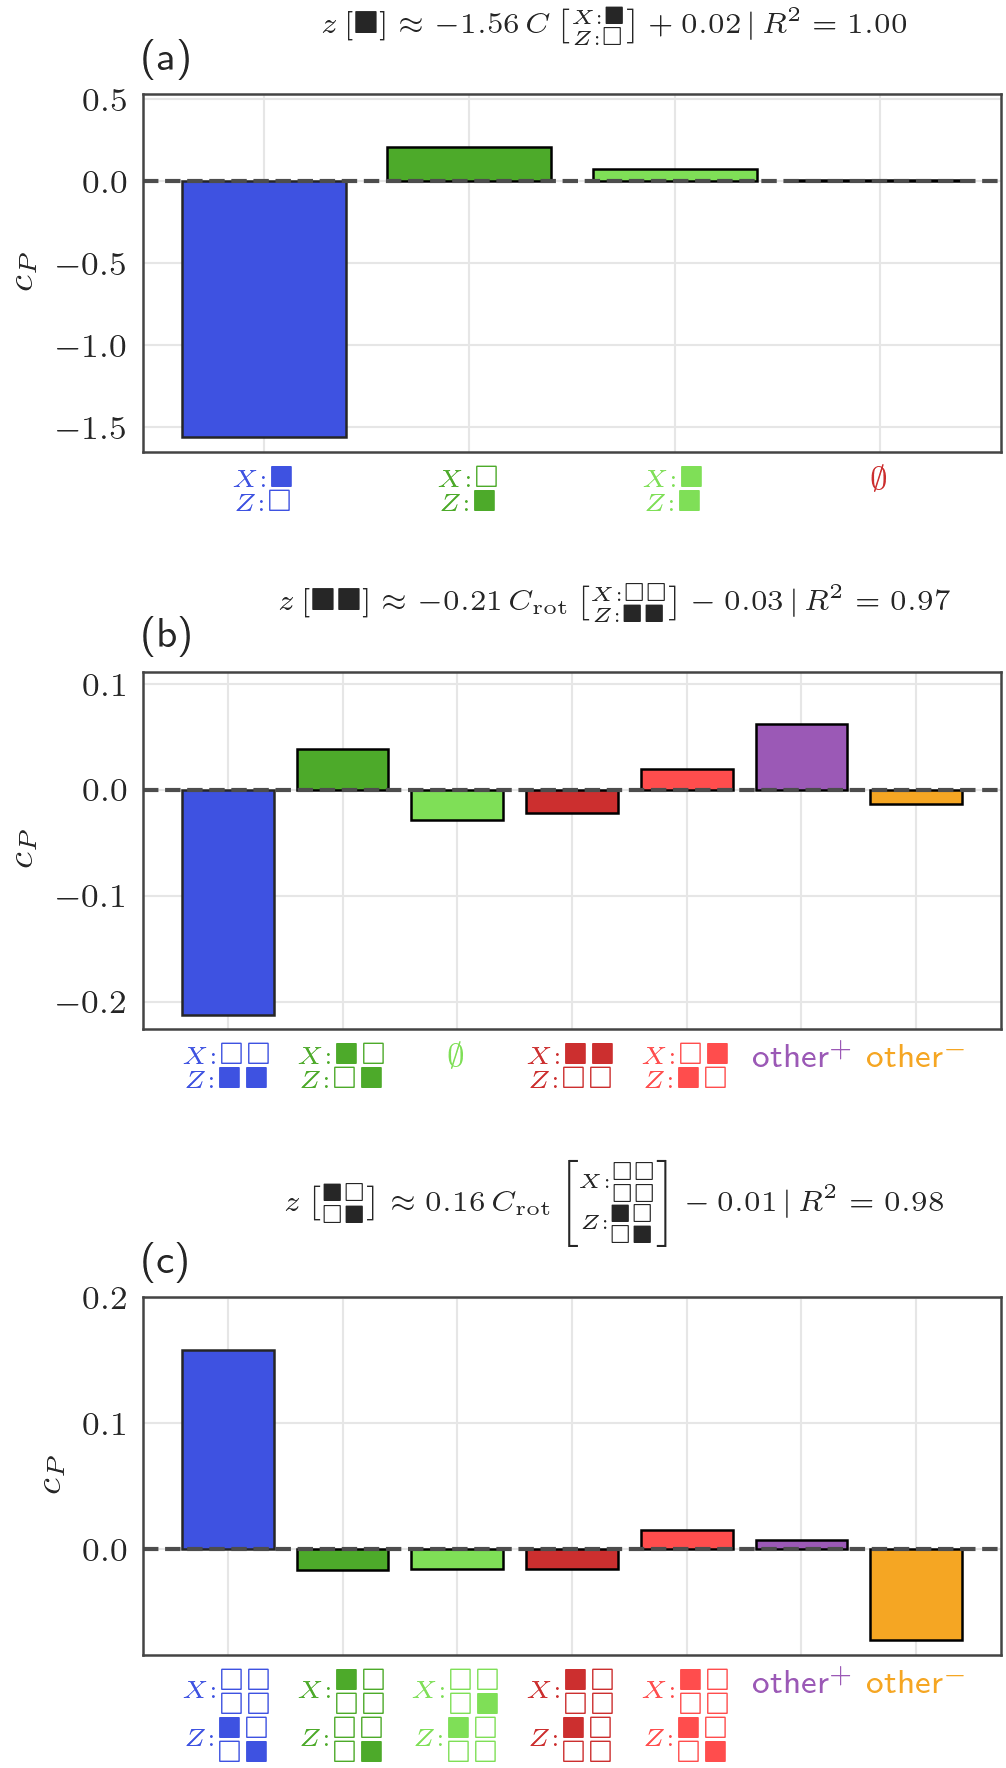

In [10]:
# (a) main text: dominant terms only, single column
fig_main = make_figure(
    panel_branches,
    max_bars=5,
    figsize=(SINGLE_WIDTH, SINGLE_WIDTH / GOLDEN * 2.9),
)
fig_main.savefig(OUTDIR / "Fig5.pdf")
print(f"wrote {OUTDIR / 'Fig5.pdf'}")

wrote Plots/Fig5_full.pdf


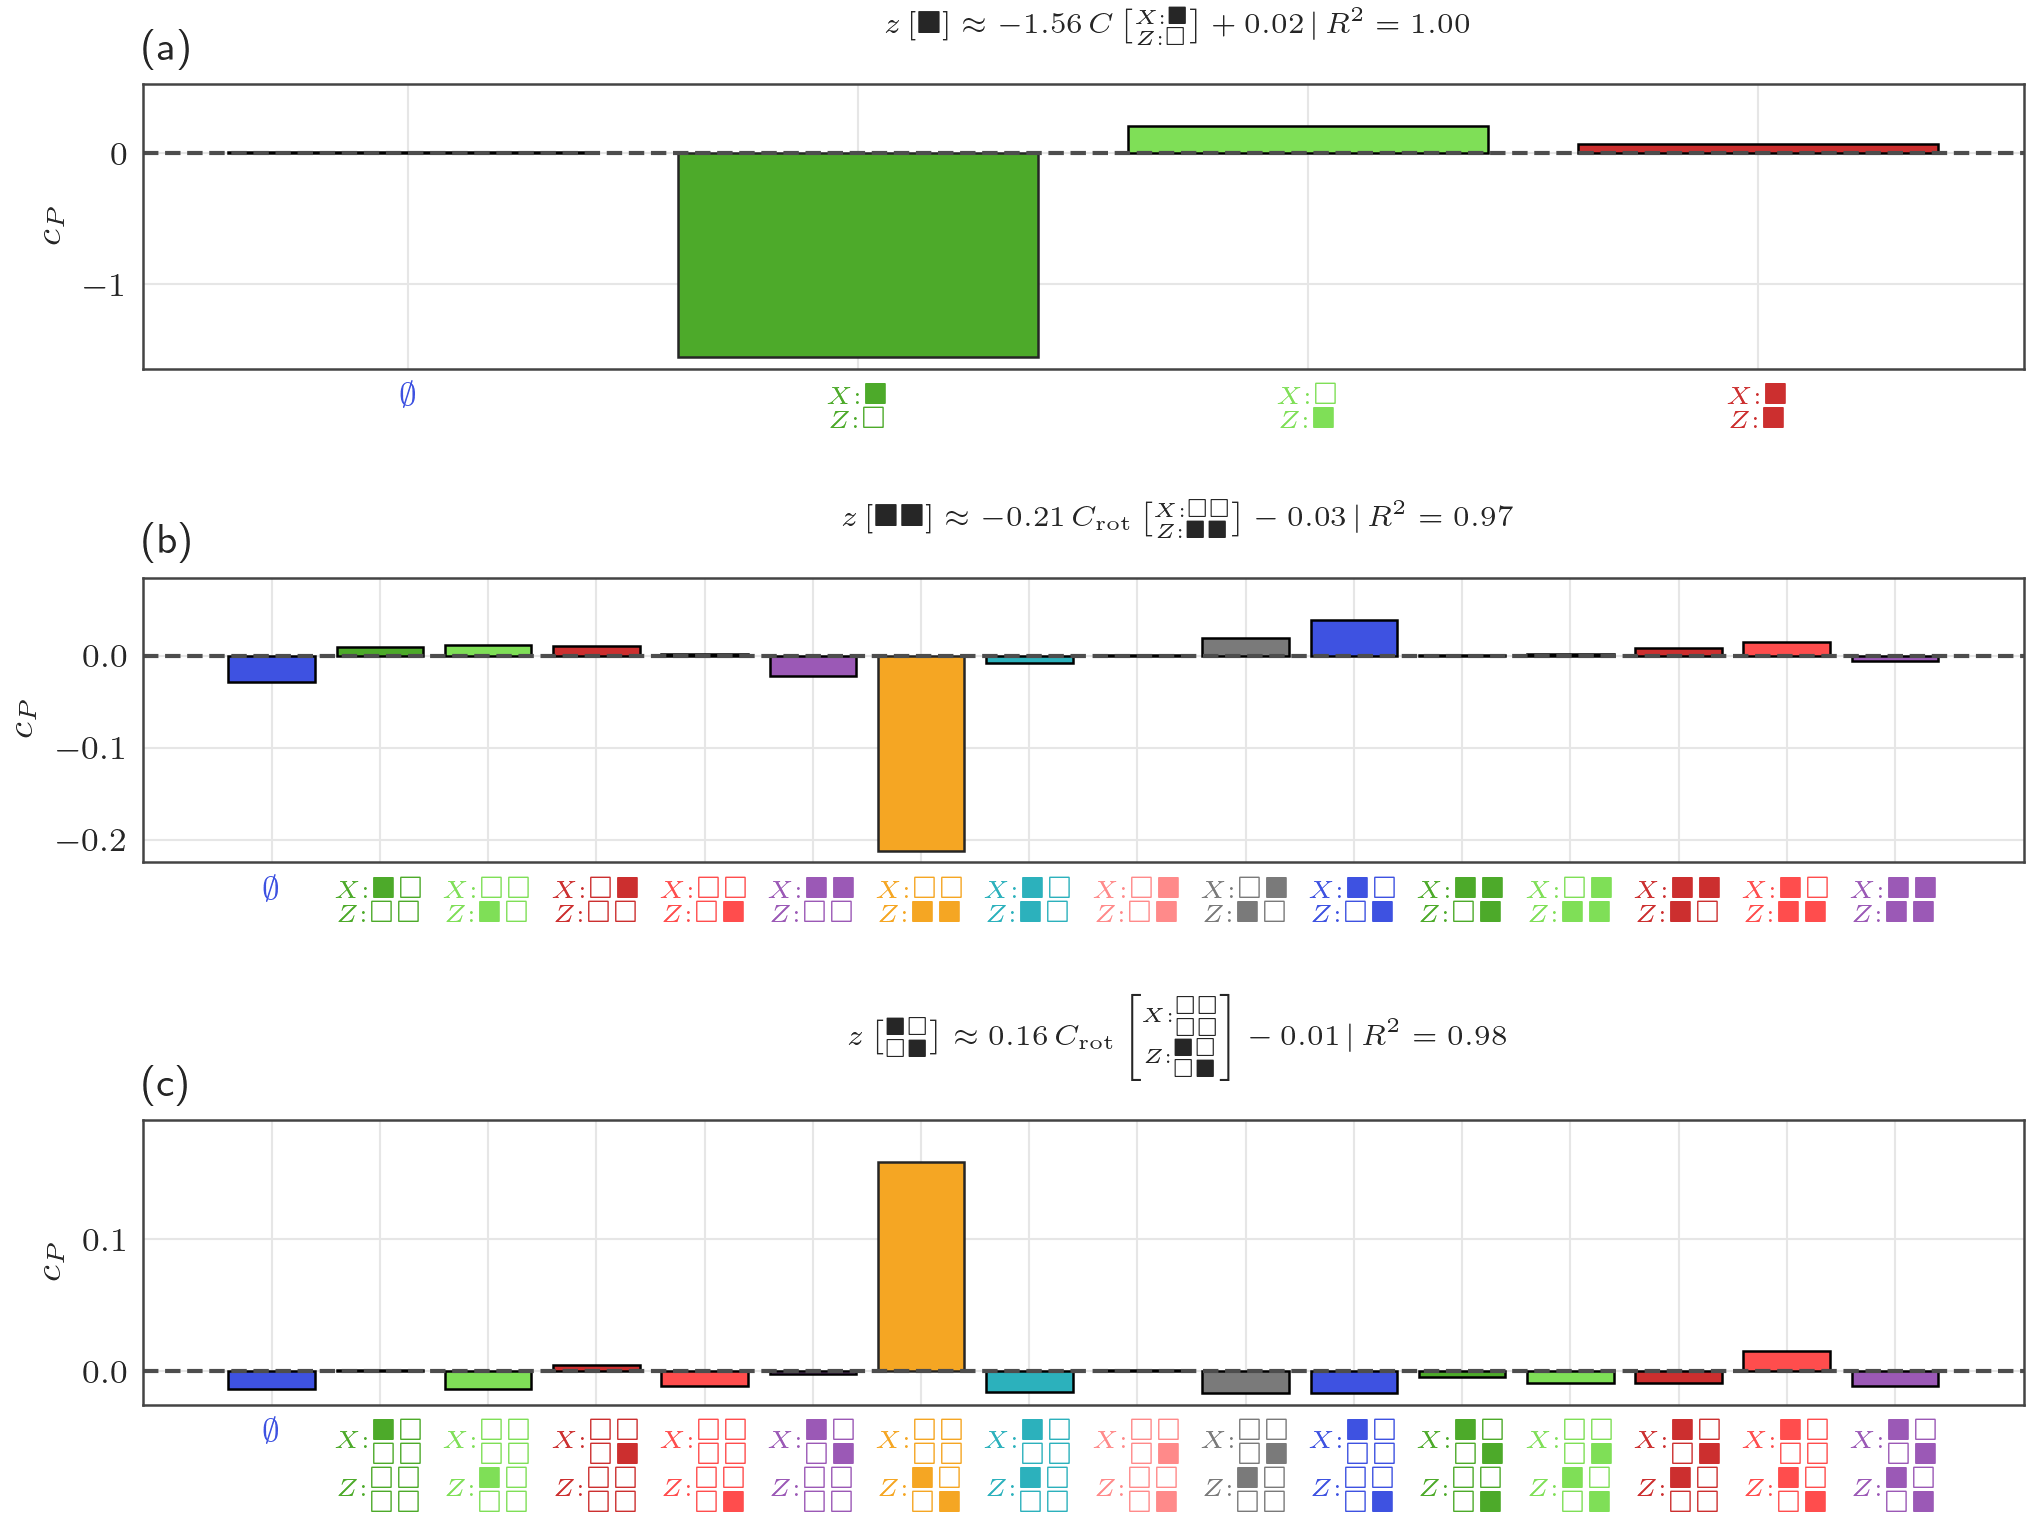

In [11]:
# (b) appendix: the complete coefficient spectrum, double column
fig_full = make_figure(
    panel_branches,
    max_bars=None,
    figsize=(DOUBLE_WIDTH, DOUBLE_WIDTH / GOLDEN * 1.25),
)
fig_full.savefig(OUTDIR / "Fig5_full.pdf")
print(f"wrote {OUTDIR / 'Fig5_full.pdf'}")

## Provenance

Printed below so the numbers quoted in the caption can be traced back to the run
that produced them.

In [12]:
print(f"run folder      : {BASEPATH}")
print(f"dataset / task  : {cf.dataset} / {cf.task}")
print(f"equivariant     : {getattr(cf, 'equivariant', False)}  group={GROUP}")
print(f"val snapshots   : {len(z)}")
print(f"selection       : forward, budget={MAX_TERMS}, "
      f"plateau_tol={PLATEAU_TOL}, floor={PLATEAU_FLOOR}\n")

hdr = (f"{'branch':>6} {'kernel':>8} {'terms':>6} {'kept':>5} {'R2_full':>9} "
       f"{'R2_kept':>9}  support")
print(hdr)
print("-" * len(hdr))
for k in panel_branches:
    r = fits[k]
    print(f"{k:>6} {str(cf.kernels[k][0]):>8} {len(r['patterns']):>6} "
          f"{len(r['selected_terms']):>5} {r['r_squared']:>9.4f} "
          f"{r['selected_r_squared']:>9.4f}  {r['selected_terms']}")

run folder      : Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
dataset / task  : Paris_XY_XZ / partition
equivariant     : True  group=C4
val snapshots   : 10124
selection       : forward, budget=5, plateau_tol=0.05, floor=0.95

branch   kernel  terms  kept   R2_full   R2_kept  support
---------------------------------------------------------
     0   [1, 1]      3     1    1.0000    0.9983  [1]
     1   [2, 1]     15     1    1.0000    0.9662  [6]
     2   [2, 2]     15     1    1.0000    0.9773  [6]
